In [1]:
import boto3
import sagemaker
from sagemaker.sklearn.estimator import SKLearn

from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import CSVDeserializer


# Create a boto3 session in us-east-2
boto_session = boto3.Session(region_name="ca-central-1")
sagemaker_session = sagemaker.Session(boto_session=boto_session)

role = "arn:aws:iam::222634404112:role/SageMakerExecutionRole-ca"
job_name = "occupancy-model-t1"


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pydantic/_internal/_fields.py:201: UserWarning: Field name "json" in "MonitoringDatasetFormat" shadows an attribute in parent "Base"
  warnings.warn(


[04/15/25 18:49:43] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=510842;file:///Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=717577;file:///Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/botocore/credentials.py#1352\1352]8;;\

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /Users/manraj/Library/Application Support/sagemaker/config.yaml


[04/15/25 18:49:44] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=23418;file:///Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=363213;file:///Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/botocore/credentials.py#1352\1352]8;;\

In [2]:
sklearn_estimator = SKLearn(
    entry_point="train.py",       # Use your training script
    source_dir=".",               # Package the current directory (which includes train.py, inference.py, requirements.txt, etc.)
    dependencies=["requirements.txt"],
    role=role,
    instance_type="ml.m5.xlarge",
    framework_version="0.23-1",
    output_path="s3://dana-minicapstone-ca/model-artifacts/",
    sagemaker_session=sagemaker_session,
    job_name=job_name
)

sklearn_estimator.fit()


                    INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=381934;file:///Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=528512;file:///Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/botocore/credentials.py#1352\1352]8;;\

                    INFO     SageMaker Python SDK will collect telemetry to help us better  ]8;id=443716;file:///Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sagemaker/telemetry/telemetry_logging.py\telemetry_logging.py]8;;\:]8;id=718304;file:///Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sagemaker/telemetry/telemetry_logging.py#91\91]8;;\
                             understand our user's needs, diagnose issues, and deliver                             
                             additional features.                                                                  
                             To opt out of telemetry, please disable via TelemetryOptOut                           
                             parameter in SDK defaults config. For more information, refer                         
                             to                                                                                    
                             https://sagemaker.readthedocs.io/en/stable/overview.html#confi                        
                             guring-and-using-defaults-with-the-sagemaker-python-sdk.                              

[04/15/25 18:49:45] INFO     Creating training-job with name:                                       ]8;id=431710;file:///Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=224929;file:///Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sagemaker/session.py#1042\1042]8;;\
                             sagemaker-scikit-learn-2025-04-16-01-49-44-625                                        

2025-04-16 01:49:46 Starting - Starting the training job...
2025-04-16 01:50:13 Starting - Preparing the instances for training...
2025-04-16 01:50:44 Downloading - Downloading the training image...
2025-04-16 01:51:20 Training - Training image download completed. Training in progress..2025-04-16 01:51:27,189 sagemaker-containers INFO     Imported framework sagemaker_sklearn_container.training
2025-04-16 01:51:27,193 sagemaker-training-toolkit INFO     No GPUs detected (normal if no gpus installed)
2025-04-16 01:51:27,239 sagemaker_sklearn_container.training INFO     Invoking user training script.
2025-04-16 01:51:27,472 sagemaker-training-toolkit INFO     Installing dependencies from requirements.txt:
/miniconda3/bin/python -m pip install -r requirements.txt
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.9/255.9 MB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 101.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.3/293.3 kB 52.5 MB/s

In [ ]:
from sagemaker.sklearn.model import SKLearnModel
from sagemaker.serializers import CSVSerializer

model = SKLearnModel(
    model_data=sklearn_estimator.model_data,
    role=role,
    entry_point="inference.py",  # Reference your inference script
    framework_version="0.23-1",
    py_version="py3",
    source_dir="."
)

predictor = model.deploy(initial_instance_count=1, instance_type="ml.m5.large")


[04/15/25 18:52:47] INFO     Creating model with name:                                              ]8;id=285705;file:///Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=957799;file:///Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sagemaker/session.py#4094\4094]8;;\
                             sagemaker-scikit-learn-2025-04-16-01-52-47-709                                        

[04/15/25 18:52:48] INFO     Creating endpoint-config with name                                     ]8;id=362168;file:///Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=133059;file:///Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sagemaker/session.py#6019\6019]8;;\
                             sagemaker-scikit-learn-2025-04-16-01-52-48-769                                        

[04/15/25 18:52:49] INFO     Creating endpoint with name                                            ]8;id=593534;file:///Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sagemaker/session.py\session.py]8;;\:]8;id=332633;file:///Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sagemaker/session.py#4841\4841]8;;\
                             sagemaker-scikit-learn-2025-04-16-01-52-48-769                                        

------!

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:27                                                                                   │
│                                                                                                  │
│   24 test_csv = response['Body'].read().decode('utf-8')                                          │
│   25                                                                                             │
│   26 # Call your endpoint with the CSV string                                                    │
│ ❱ 27 result = predictor.predict(test_csv)                                                        │
│   28 print("Predictions from endpoint:\n", result)                                               │
│   29                                                                                             │
│                                                                                                  │
│ /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sagemaker/base_p │
│ redictor.py:212 in predict                                                                       │
│                                                                                                  │
│   209 │   │   if inference_component_name:                                                       │
│   210 │   │   │   request_args["InferenceComponentName"] = inference_component_name              │
│   211 │   │                                                                                      │
│ ❱ 212 │   │   response = self.sagemaker_session.sagemaker_runtime_client.invoke_endpoint(**req   │
│   213 │   │   return self._handle_response(response)                                             │
│   214 │                                                                                          │
│   215 │   def _handle_response(self, response):                                                  │
│                                                                                                  │
│ /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/botocore/client. │
│ py:570 in _api_call                                                                              │
│                                                                                                  │
│    567 │   │   │   │   │   f"{py_operation_name}() only accepts keyword arguments."              │
│    568 │   │   │   │   )                                                                         │
│    569 │   │   │   # The "self" in this scope is referring to the BaseClient.                    │
│ ❱  570 │   │   │   return self._make_api_call(operation_name, kwargs)                            │
│    571 │   │                                                                                     │
│    572 │   │   _api_call.__name__ = str(py_operation_name)                                       │
│    573                                                                                           │
│                                                                                                  │
│ /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/botocore/context │
│ .py:124 in wrapper                                                                               │
│                                                                                                  │
│   121 │   │   │   with start_as_current_context():                                               │
│   122 │   │   │   │   if hook:                                                                   │
│   123 │   │   │   │   │   hook()                                                                 │
│ ❱ 124 │   │   │   │   return func(*args, **kwargs)                                               │
│   125 │   │                                                

In [ ]:
predictor.serializer = CSVSerializer()
predictor.deserializer = CSVDeserializer()

s3 = boto3.client('s3', region_name='ca-central-1')
bucket_name = "dana-minicapstone-ca"
test_key = "data/hvac_test.csv"
response = s3.get_object(Bucket=bucket_name, Key=test_key)
test_csv = response['Body'].read().decode('utf-8')

result = predictor.predict(test_csv)
print("Predictions from endpoint:\n", result)

Predictions from endpoint:
 [['Predicted_HVAC_kWh'], ['-0.09174354187602107'], ['3.9120071056391352'], ['3.137175181411598'], ['2.966215058042277'], ['-0.11315997674233036'], ['3.0042134049680187'], ['2.8470372272090687'], ['2.8244327539119487'], ['-0.14287483855908123'], ['2.9517269434932683'], ['2.8550756104811086'], ['2.7893357040904867'], ['-0.07010931953152011'], ['2.918200936427664'], ['2.734903422250066'], ['2.7488925130702073'], ['-0.11584084365026959'], ['2.86484113154028'], ['2.733579205700158'], ['2.90497906716871'], ['0.1801117371240275'], ['3.028146998662656'], ['2.9271651197857143'], ['2.918699497977115'], ['0.16863090712157103'], ['2.9433605470230026'], ['2.819047500842749'], ['2.7659206877762874'], ['0.07863626930630563'], ['2.7595400548479603'], ['2.3827292102700337'], ['2.5123513947868865'], ['0.03604726215447751'], ['2.5136448240826073'], ['2.3049221248619975'], ['2.310756800069243'], ['-0.15524340755057886'], ['3.3684540147141933'], ['2.917948149294052'], ['2.856590

Predictions DataFrame:


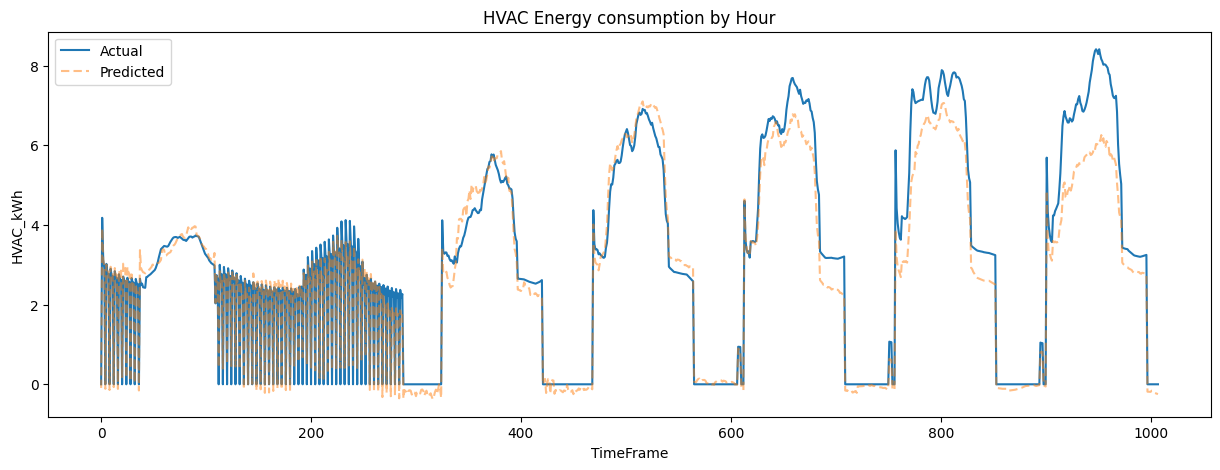

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/Users/manraj/Documents/GitHub/Dana-4830/HVAC_Test_Data_Files/hvac_test_actual_1.csv')

df.columns = df.columns.str.replace(r"^b'|'$|\[.*?\]", "", regex=True)
df = df.loc[df['Environment:Site Day Type Index'] != 0]
df["HVAC_kWh"] = df["Electricity:HVAC"] * 2.77778e-7
df.drop(columns='Electricity:HVAC', axis=1, inplace=True)

df_predictions = pd.DataFrame(result[1:], columns=result[0])
df_predictions['Predicted_HVAC_kWh'] = df_predictions['Predicted_HVAC_kWh'].astype(float)
print("Predictions DataFrame:")

plt.figure(figsize=(15, 5))
sns.lineplot(x=df.index, y=df['HVAC_kWh'], label='Actual')
sns.lineplot(x=df_predictions.index, y=df_predictions['Predicted_HVAC_kWh'], label='Predicted', dashes=(4,2), alpha=0.5)
plt.title('HVAC Energy consumption by Hour')
plt.xlabel('TimeFrame')
plt.legend()
plt.show()